# Data Visualiztion with seaborn
Seaborn is a Python visualization library based on Matplotlib that provides a high-level interface for drawing
attractive and informative statistical graphics. Seaborn helps in creating complex visualizations with just a few
lines of code. In this lesson, we will cover the basics of Seaborn, including creating various types of plots and
customizing them.

In [1]:
! pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importingthe seaborn 
import seaborn as sns


In [ ]:
# basic plottingwith the seaborn
data = sns.load_dataset('tips') # we have loaded the example dataset provided by the  
data

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


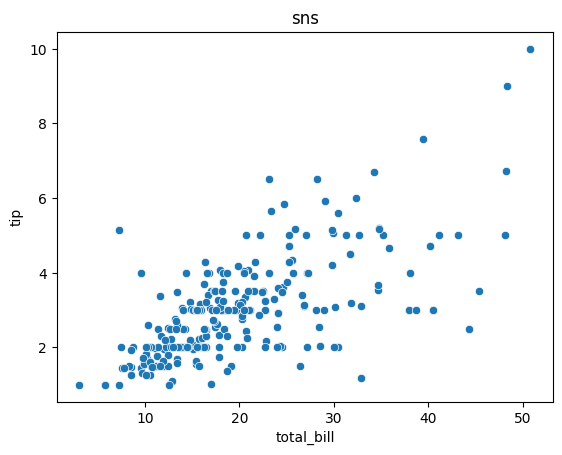

In [ ]:
# ploattingan scatter plot 
import matplotlib.pyplot as plt
sns.scatterplot(x = "total_bill" , y = "tip" , data = data)
plt.title("sns")
plt.show() 
# hwlps to find the raltions ship btw total_bill and tip

<Axes: xlabel='size', ylabel='total_bill'>

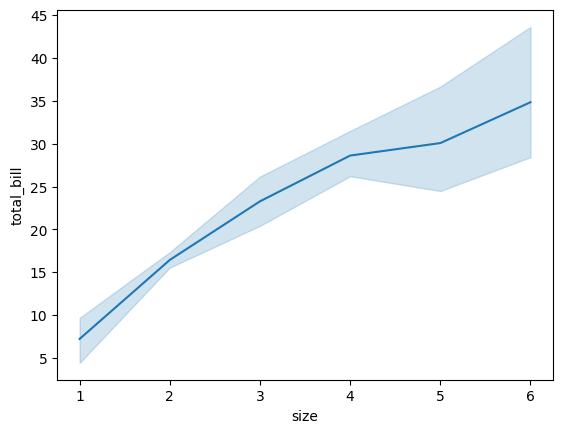

In [6]:
# lineplot
# size in the datasset size at the table measn how many people are sitting at an table
sns.lineplot(x ='size' , y = 'total_bill' , data = data)

Text(0.5, 1.0, 'barplot')

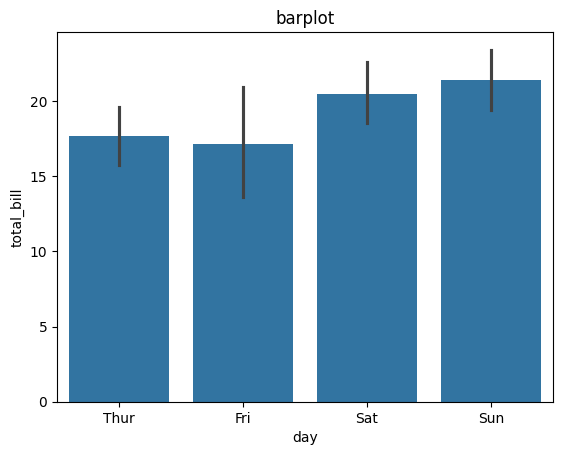

In [9]:
# 3 categorical variable 
# categorical var present in the dat set are --1-- smokers , 2--- days 
# base on the dayswe wantteh total bills 
sns.barplot(x = 'day' , y = 'total_bill', data = data)
plt.title('barplot')

Text(0.5, 1.0, 'box')

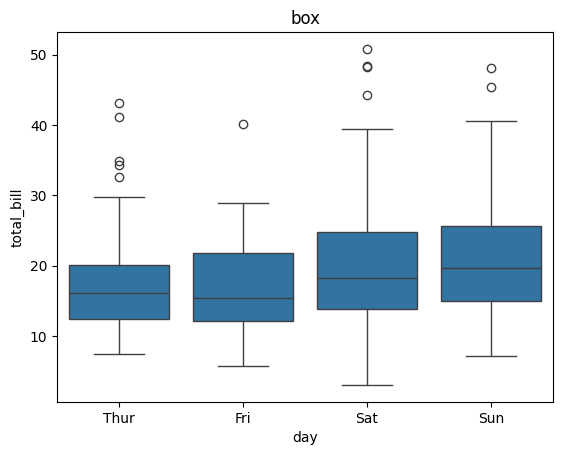

In [ ]:
# box plot 
sns.boxplot(x = 'day' , y= 'total_bill'  , data = data)
plt.title('box')

# the circle we see below are all the outliers 
# on yaxis the value indiacte teh percentage 

<Axes: xlabel='day', ylabel='total_bill'>

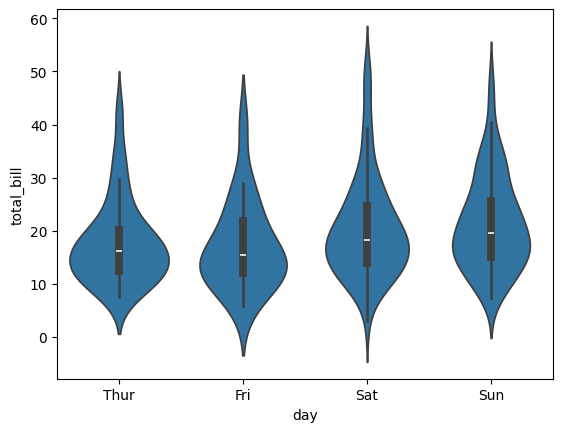

In [ ]:

# FOR DISTRIBUTION WE AN ALSO USE OF THE MED=TOD CALLED AS THE VILON PLOT 
# vilon plot
sns.violinplot(x = 'day' , y= 'total_bill'  , data = data)
# so we can seethe disticuiton is higher at teh y axis around 15 (which indicate the means )

<Axes: xlabel='total_bill', ylabel='Count'>

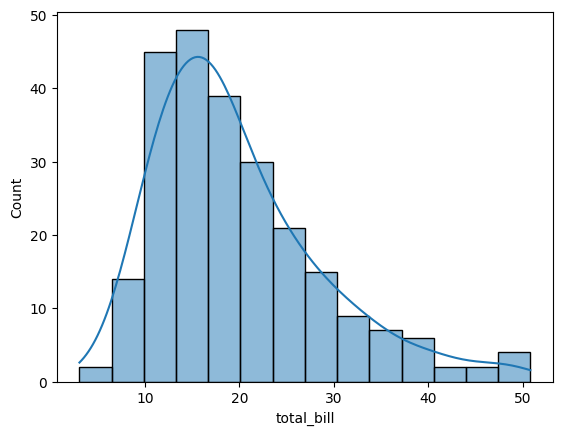

In [ ]:
# 3 hsitogrm
sns.histplot(data = data , x = 'total_bill' , kde = True) # kde ---- it helps in the visualization of teh curve 

<Axes: xlabel='total_bill', ylabel='Density'>

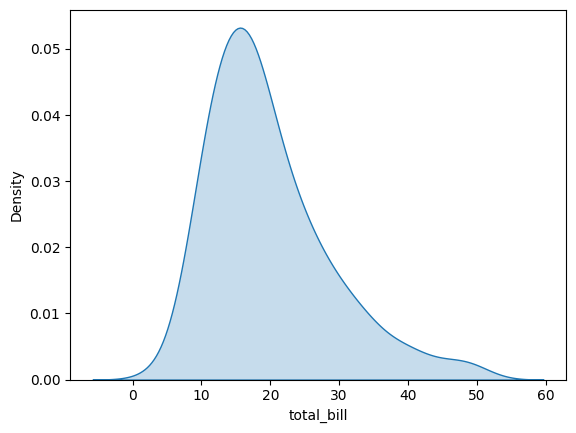

In [16]:
# kde plot 
sns.kdeplot(data = data , x = 'total_bill' , fill = True)

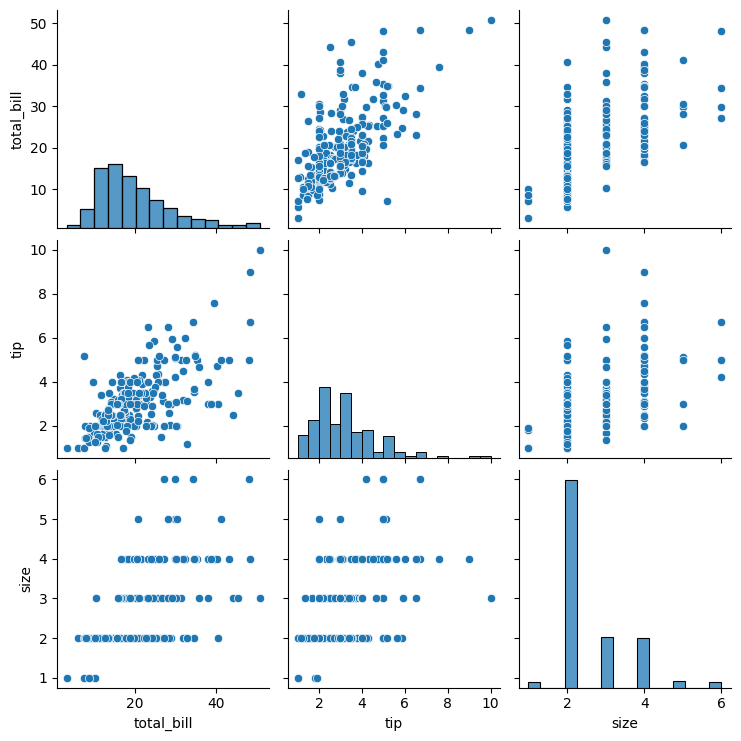

In [17]:
# 3 pair plot 
#  if we want to see the realtion btw all the variable  to diff diff varialbes 
sns.pairplot(data)

In [19]:
# heat map 
corr = data[['total_bill' , 'size' , 'tip']].corr()
# this show the relation between one feature to other 
# so we can see if the the bill increase then the "tip"  aslo incereae upto 0.6 %
corr


,total_bill,size,tip
total_bill,1.000000,0.598315,0.675734
size,0.598315,1.000000,0.489299
tip,0.675734,0.489299,1.000000


<Axes: >

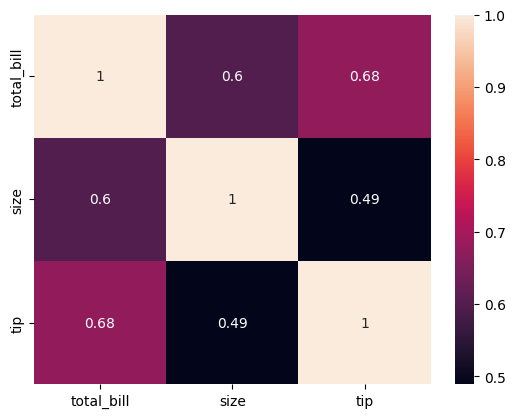

In [20]:
sns.heatmap(corr , annot = True ) # annnot indicate teh annotations

In [25]:
# modifying athe plots asnd making changes as per our need 


import pandas as pd 
df = pd.read_csv('data.csv')
df.head(5)

,Date,Category,Value,Product,Sales,Region
0,2023-01-01,A,28.0,Product1,754.0,East
1,2023-01-02,B,39.0,Product3,110.0,North
2,2023-01-03,C,32.0,Product2,398.0,East
3,2023-01-04,B,8.0,Product1,522.0,East
4,2023-01-05,B,26.0,Product3,869.0,North


Text(0.5, 1.0, 'barplot')

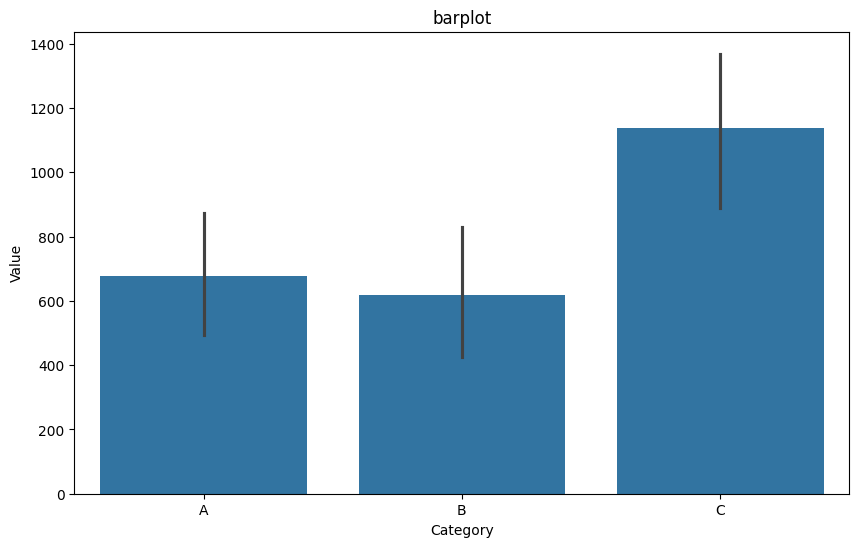

In [28]:
# ploting total sales by product 
plt.figure(figsize = (10 ,6) )
sns.barplot( x = 'Category' , y = 'Value' , data = df , estimator = sum ) # E # estimator helps in the calculation
plt.title('barplot')

# reconstruction of data fro better visualization 



1. some data may not be always proper so we reconstruc the  data 
2. this is done using the pd.melt() function 

Think of `pd.melt()` as **turning wide data into long data**.

### Before `melt()`

Suppose `segment_analysis` looks like this:

| segment     | sales | profit |
| ----------- | ----: | -----: |
| Consumer    | 50000 |   8000 |
| Corporate   | 30000 |   4000 |
| Home Office | 20000 |   3000 |

Here, **sales** and **profit** are separate columns.

---

### After `melt()`

```python
segment_melted = pd.melt(
    segment_analysis,
    id_vars='segment', 
    var_name='metric',
    value_name='amount'
)
# here --id_vars = 'segment' , indicate that the this column will reamin same 
 
```

Becomes:

| segment     | metric | amount |
| ----------- | ------ | -----: |
| Consumer    | sales  |  50000 |
| Corporate   | sales  |  30000 |
| Home Office | sales  |  20000 |
| Consumer    | profit |   8000 |
| Corporate   | profit |   4000 |
| Home Office | profit |   3000 |

---

### What happened?

* `segment` stays the same (`id_vars='segment'`)
* Column names (`sales`, `profit`) move into a new column called `metric`
* Their values move into a new column called `amount`

So:

```python
sales = 50000
```

becomes

```python
metric = 'sales'
amount = 50000
```

---

### Why do this?

Seaborn likes data in this "long" format for grouped charts.

Then you can do:

```python
sns.barplot(
    data=segment_melted,
    x='segment',
    y='amount',
    hue='metric'
)
```

and get:

* One bar for Sales
* One bar for Profit

for each segment.

### Easy way to remember

**Before melt:**

```
Consumer | Sales | Profit
```

**After melt:**

```
Consumer | Sales  | 50000
Consumer | Profit | 8000
```

So `melt()` **converts columns into rows**, which makes it easier for Seaborn to compare multiple metrics in the same chart.


## tricks

This is actually one of the most common struggles in data analysis interviews. The good news is that you don't need to memorize dozens of charts. You can choose the right visualization by asking **one question**:

> **What am I trying to compare?**

---

# 1. Comparing Categories → Bar Chart

When comparing regions, products, categories, cities, etc.

**Questions like:**

* Which region has the highest profit?
* Top 5 sub-categories by sales?
* Which customer segment generates the most revenue?

**Use:**

```python
plt.bar(...)
# or
series.plot(kind='bar')
```

**Examples from your project:**

* Revenue by category
* Profit by region
* Top 5 sub-categories

✅ Interview rule:

> If the X-axis contains names/categories, use a bar chart.

---

# 2. Trends Over Time → Line Chart

When the question contains:

* trend
* growth
* over time
* monthly
* yearly
* daily

**Use:**

```python
plt.plot(...)
```

**Examples:**

* Monthly sales trend
* Yearly revenue growth
* Daily orders trend

✅ Interview rule:

> If time is on the X-axis, use a line chart.

---

# 3. Part of a Whole → Pie Chart

When asking:

* Market share
* Percentage contribution
* Distribution of total sales

Example:

```python
df.groupby('segment')['sales'].sum().plot(kind='pie')
```

Example question:

> What percentage of sales comes from each customer segment?

⚠️ Use only when there are 5-6 categories or fewer.

---

# 4. Relationship Between Two Numbers → Scatter Plot

Question contains:

* relationship
* correlation
* impact
* influence

Examples:

* Does discount affect profit?
* Does quantity sold affect revenue?

Use:

```python
plt.scatter(df['discount'], df['profit'])
```

✅ Interview rule:

> Two numeric variables → Scatter plot.

---

# 5. Distribution of One Variable → Histogram

Question contains:

* distribution
* spread
* frequency

Examples:

* How are sales distributed?
* How are profits distributed?

Use:

```python
plt.hist(df['sales'])
```

---

# 6. Rankings → Horizontal Bar Chart

Questions:

* Top 10 products
* Top 5 cities
* Bottom 10 products

Use:

```python
top10.plot(kind='barh')
```

Looks cleaner than vertical bars.

---

# The 5-Second Interview Trick

When you see a question, classify it:

| Question Type                | Chart        |
| ---------------------------- | ------------ |
| Compare categories           | Bar Chart    |
| Trend over time              | Line Chart   |
| Percentage/share             | Pie Chart    |
| Relationship between numbers | Scatter Plot |
| Distribution                 | Histogram    |

---

# Applying to Your Mumbai Retail Project

| Business Question        | Visualization |
| ------------------------ | ------------- |
| Revenue by Category      | Bar Chart     |
| Top 5 Sub-Categories     | Bar Chart     |
| Profit by Region         | Bar Chart     |
| Monthly Revenue Trend    | Line Chart    |
| Yearly Growth            | Line Chart    |
| Discount vs Profit       | Scatter Plot  |
| Sales Distribution       | Histogram     |
| Segment Share of Revenue | Pie Chart     |

---

### Interview Tip

When asked *"Why did you choose this visualization?"*, answer like this:

> "I used a bar chart because the objective was to compare performance across categorical groups (regions/sub-categories)."

or

> "I used a line chart because the analysis focused on trends over time, and line charts clearly show growth and seasonality patterns."

That single sentence sounds very professional and is exactly what interviewers want to hear.
